In [1]:
import os

import numpy as np
import pandas as pd
import plotly.graph_objs as go
import plotly.offline as py
from scipy.stats import skew

from utils import get_logger, load_config

py.init_notebook_mode(connected=True)


logger = get_logger()

cfg = load_config("configuration.yaml")

# Visualization


In [12]:
train = pd.read_csv(
    os.path.join(
        cfg["path"]["processed_data"],
        "train" + "_" + str(cfg["FEATURE_ENGINEERING"]["version"]) + ".csv",
    )
)
test = pd.read_csv(
    os.path.join(
        cfg["path"]["processed_data"],
        "test" + "_" + str(cfg["FEATURE_ENGINEERING"]["version"]) + ".csv",
    )
)

train_original = pd.read_csv(cfg["path"]["train_path"])
test_original = pd.read_csv(cfg["path"]["test_path"])


In [3]:
def hist_perc(df_col, bin_size, rng_st, rng_end):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    # plt.hist(x = train.RevolvingUtilizationOfUnsecuredLines,bins=10,range=(,1))
    plt.hist(x=df_col, bins=bin_size, range=(rng_st, rng_end))
    formatter = mticker.FuncFormatter(
        lambda v, pos: str(round((v * 100 / train.shape[0]), 2))
    )
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()

In [4]:
def plotHist(df, nameOfFeature):
    cls_train = df[nameOfFeature]
    data_array = cls_train
    hist_data = np.histogram(data_array)
    binsize = 0.5

    trace1 = go.Histogram(
        x=data_array,
        histnorm="",
        name="Histogram of Wind Speed",
        autobinx=False,
        xbins=dict(
            start=df[nameOfFeature].min() - 1,
            end=df[nameOfFeature].max() + 1,
            size=binsize,
        ),
    )

    trace_data = [trace1]
    layout = go.Layout(
        bargroupgap=0.3,
        title="The distribution of " + nameOfFeature,
        xaxis=dict(
            title=nameOfFeature,
            titlefont=dict(
                family="Courier New, monospace", size=18, color="#7f7f7f"
            ),
        ),
        yaxis=dict(
            title="Number of labels",
            titlefont=dict(
                family="Courier New, monospace", size=19, color="#7f7f7f"
            ),
        ),
    )
    fig = go.Figure(data=trace_data, layout=layout)
    py.iplot(fig)

In [5]:
from scipy.stats import kurtosis


def plotBarCat(df, feature, target):
    x0 = df[df[target] == 0][feature]
    x1 = df[df[target] == 1][feature]

    trace1 = go.Histogram(x=x0, opacity=0.75)
    trace2 = go.Histogram(x=x1, opacity=0.75)

    data = [trace1, trace2]
    layout = go.Layout(
        barmode="overlay", title=feature, yaxis=dict(title="Count")
    )
    fig = go.Figure(data=data, layout=layout)

    py.iplot(fig, filename="overlaid histogram")

    def DescribeFloatSkewKurt(df, target):
        """
        A fundamental task in many statistical analyses is to characterize
        the location and variability of a data set. A further
        characterization of the data includes skewness and kurtosis.
        Skewness is a measure of symmetry, or more precisely, the lack
        of symmetry. A distribution, or data set, is symmetric if it
        looks the same to the left and right of the center point.
        Kurtosis is a measure of whether the data are heavy-tailed
        or light-tailed relative to a normal distribution. That is,
        data sets with high kurtosis tend to have heavy tails, or
        outliers. Data sets with low kurtosis tend to have light
        tails, or lack of outliers. A uniform distribution would
        be the extreme case
        """
        print("-*-" * 25)
        print(f"{target} mean : ", np.mean(df[feature]))
        print(f"{target} var  : ", np.var(df[feature]))
        print(f"{target} skew : ", skew(df[feature]))
        print(f"{target} kurt : ", kurtosis(df[feature]))
        print("-*-" * 25)

    DescribeFloatSkewKurt(df, feature)

In [6]:
def OutLiersBox(df, nameOfFeature):
    trace0 = go.Box(
        y=df[nameOfFeature],
        name="All Points",
        jitter=0.3,
        pointpos=-1.8,
        boxpoints="all",
        marker=dict(color="rgb(7,40,89)"),
        line=dict(color="rgb(7,40,89)"),
    )

    trace1 = go.Box(
        y=df[nameOfFeature],
        name="Only Whiskers",
        boxpoints=False,
        marker=dict(color="rgb(9,56,125)"),
        line=dict(color="rgb(9,56,125)"),
    )

    trace2 = go.Box(
        y=df[nameOfFeature],
        name="Suspected Outliers",
        boxpoints="suspectedoutliers",
        marker=dict(
            color="rgb(8,81,156)",
            outliercolor="rgba(219, 64, 82, 0.6)",
            line=dict(outliercolor="rgba(219, 64, 82, 0.6)", outlierwidth=2),
        ),
        line=dict(color="rgb(8,81,156)"),
    )

    trace3 = go.Box(
        y=df[nameOfFeature],
        name="Whiskers and Outliers",
        boxpoints="outliers",
        marker=dict(color="rgb(107,174,214)"),
        line=dict(color="rgb(107,174,214)"),
    )

    data = [trace0, trace1, trace2, trace3]

    layout = go.Layout(title=f"{nameOfFeature} Outliers")

    fig = go.Figure(data=data, layout=layout)
    py.iplot(fig, filename="Outliers")

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import svm
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor


def OutLierDetection(df, feature1, feature2, outliers_fraction=0.1):
    new_df = df.copy()
    rng = np.random.RandomState(42)

    # Example settings
    n_samples = new_df.shape[0]
    #     outliers_fraction = 0.2 # ************************************** imp
    clusters_separation = [0]  # , 1, 2]

    # define two outlier detection tools to be compared
    classifiers = {
        "One-Class SVM": svm.OneClassSVM(
            nu=0.95 * outliers_fraction + 0.05, kernel="rbf", gamma=0.1
        ),
        "Robust covariance": EllipticEnvelope(contamination=outliers_fraction),
        "Isolation Forest": IsolationForest(
            max_samples=n_samples,
            contamination=outliers_fraction,
            random_state=rng,
        ),
        "Local Outlier Factor": LocalOutlierFactor(
            n_neighbors=35, contamination=outliers_fraction
        ),
    }

    xx, yy = np.meshgrid(
        np.linspace(
            new_df[feature1].min() - new_df[feature1].min() * 10 / 100,
            new_df[feature1].max() + new_df[feature1].max() * 10 / 100,
            50,
        ),
        np.linspace(
            new_df[feature2].min() - new_df[feature2].min() * 10 / 100,
            new_df[feature2].max() + new_df[feature2].max() * 10 / 100,
            50,
        ),
    )

    n_inliers = int((1.0 - outliers_fraction) * n_samples)
    n_outliers = int(outliers_fraction * n_samples)
    ground_truth = np.ones(n_samples, dtype=int)
    ground_truth[-n_outliers:] = -1

    # Fit the problem with varying cluster separation
    for i, offset in enumerate(clusters_separation):
        np.random.seed(42)
        # Data generation

        X = new_df[[feature1, feature2]].values.tolist()

        # Fit the model
        plt.figure(figsize=(9, 7))
        for i, (clf_name, clf) in enumerate(classifiers.items()):
            # fit the data and tag outliers
            if clf_name == "Local Outlier Factor":
                y_pred = clf.fit_predict(X)
                scores_pred = clf.negative_outlier_factor_
            else:
                clf.fit(X)
                scores_pred = clf.decision_function(X)
                y_pred = clf.predict(X)
            threshold = stats.scoreatpercentile(
                scores_pred, 100 * outliers_fraction
            )
            n_errors = (y_pred != ground_truth).sum()

            unique, counts = np.unique(y_pred, return_counts=True)
            print(clf_name, dict(zip(unique, counts, strict=False)))

            new_df[feature1 + "_" + feature2 + clf_name] = y_pred
            #             print(clf_name,y_pred)
            # plot the levels lines and the points
            if clf_name == "Local Outlier Factor":
                # decision_function is private for LOF
                Z = clf._decision_function(np.c_[xx.ravel(), yy.ravel()])
            else:
                Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            subplot = plt.subplot(2, 2, i + 1)
            subplot.contourf(
                xx,
                yy,
                Z,
                levels=np.linspace(Z.min(), threshold, 7),
                cmap=plt.cm.Blues_r,
            )
            a = subplot.contour(
                xx, yy, Z, levels=[threshold], linewidths=2, colors="red"
            )
            subplot.contourf(
                xx, yy, Z, levels=[threshold, Z.max()], colors="orange"
            )
            b = plt.scatter(
                new_df[feature1],
                new_df[feature2],
                c="white",
                s=20,
                edgecolor="k",
            )

            subplot.axis("tight")

            subplot.set_xlabel("%s" % (feature1))

            plt.ylabel(feature2)  # , fontsize=18)
            plt.title("%d. %s (errors: %d)" % (i + 1, clf_name, n_errors))

        plt.subplots_adjust(0.04, 0.1, 0.96, 0.94, 0.1, 0.26)
    #         plt.suptitle("Outlier detection")

    plt.show()
    return new_df

2025-04-23 16:18 - DEBUG - matplotlib data path: /home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data
2025-04-23 16:18 - DEBUG - CONFIGDIR=/home/brice/.config/matplotlib
2025-04-23 16:18 - DEBUG - interactive is False
2025-04-23 16:18 - DEBUG - platform is linux
2025-04-23 16:18 - DEBUG - CACHEDIR=/home/brice/.cache/matplotlib
2025-04-23 16:18 - DEBUG - Using fontManager instance from /home/brice/.cache/matplotlib/fontlist-v390.json


In [8]:
train.shape

(72431, 25)

2025-04-23 16:18 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-23 16:18 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-23 16:18 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-04-23 16:18 - DEBUG - findfont: score(FontEntry(fname='/home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmb10.ttf', name='cmb10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-23 16:18 - DEBUG - findfont: score(FontEntry(fname='/home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2025-04-23 16:18 - DEBUG - findfont: score(FontEntry(fname='/home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-23 16:18 - DEBUG - findfont: score(FontEntry(fname='/home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 0.05
2025-04-23 16:18 - DEBUG - findfont: score(FontEntry(fname='/home/brice/Documents/PERSONAL_PROJECT/IASD_Kaggle/IASD_Kaggle_HW1/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-23 16:18 - DEBUG - findfont: score

<Axes: xlabel='TARGET'>

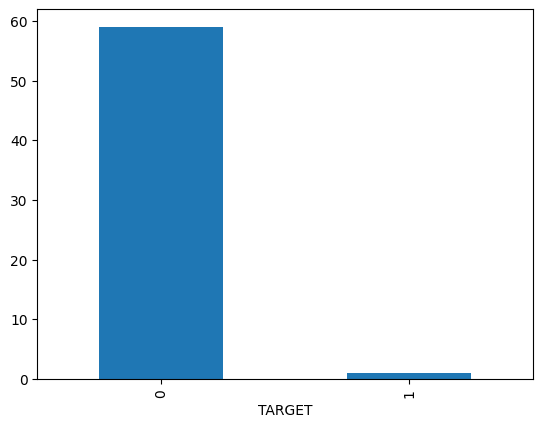

In [ ]:
train[(train["var5"] == 0)].TARGET.value_counts().plot.bar()

In [13]:
OutLiersBox(train, "var6")
OutLiersBox(train_original, "var6")

var1 correspond à RevolvingUtilizationOfUnsecuredLines : le taux d'utilisation des lignes de crédit renouvelables.

var2 correspond à age : l'âge de l'emprunteur.

var3 correspond à NumberOfTime30-59DaysPastDueNotWorse : le nombre de fois où l'emprunteur a été en retard de 30 à 59 jours sur un paiement.

var4 correspond à DebtRatio : le ratio dettes/revenus mensuels.

var5 correspond à MonthlyIncome : le revenu mensuel.

var6 correspond à NumberOfOpenCreditLinesAndLoans : le nombre de lignes de crédit et de prêts ouverts.

var7 correspond à NumberOfTimes90DaysLate : le nombre de fois où l'emprunteur a été en retard de 90 jours ou plus.

var8 correspond à NumberRealEstateLoansOrLines : le nombre de prêts immobiliers ou lignes de crédit.

var9 correspond à NumberOfTime60-89DaysPastDueNotWorse : le nombre de fois où l'emprunteur a été en retard de 60 à 89 jours.

var10 correspond à NumberOfDependents : le nombre de personnes à charge.


In [11]:
logger.info("\nSkewness des variables :")
for col in numerical_cols:
    s = skew(df[col].dropna())
    logger.info(f"{col} : skewness = {s:.2f}")

2025-04-23 16:18 - INFO - 
Skewness des variables :


NameError: name 'numerical_cols' is not defined